##### Project 2 — Triage Latency Prediction & Combined Modeling Phase
##### Delayed-Regime Target Design → Stage-1 Classification → Stage-2 Conditional Regression

##### Objective

Investigate whether triage latency is better modeled as a two-stage operational process:

Stage 1:-  Will this complaint experience a meaningful delay?

Stage 2:-  If delayed, how long will the delay be?

##### Core Modeling Question

- Can separating the dominant immediate-processing regime from the
rare delayed-processing regime produce a more useful operational model
than the one-stage regression evaluated previously?

##### Important Rules

1. Temporal train/validation/test split remains frozen.
2. Test data is NOT used for model selection.
3. No post-intake features are allowed.
4. Product/Sub-product/Issue/Sub-issue/Tags remain conditional on
   operational availability at prediction time.
5. Long-delay observations are not removed as outliers.
6. Business usefulness is evaluated separately from statistical performance.

##### Why a Two-Stage Model?

Notebook 05 demonstrated:

- strong overprediction of immediate cases
- severe underprediction of long delays
- prediction compression toward the center
- very poor recall for >7-day delays

Notebook 06 additionally showed:

- strong temporal change in long-delay prevalence
- major differences between train/validation/test tail prevalence
- a dominant immediate regime
- a relatively small delayed regime

Therefore, we test whether latency is better represented as:

                Complaint received
                       │
                       ▼
              Delayed regime?
                /          \
              No            Yes
              │              │
              ▼              ▼
       near-immediate    duration model
           process             │
                              ▼
                       predicted delay

This is a modeling hypothesis.

It must be tested against baselines rather than assumed to be superior.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.pipeline import FeatureUnion
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

##### Frozen Data Split

We reuse the temporal split from Notebook 03.

Train:- 2026-03-01 → 2026-05-27

Validation:- 2026-05-27 → 2026-06-17

Test:- 2026-06-17 → 2026-08-11

- The test set remains frozen and will not influence decisions.

In [3]:
PROJECT_ROOT = Path.cwd().parent.parent
# RAW_PATH = Path(r"D:\GURU_PROJECTS\CFPB-Financial-Consumer-Complaint-Intelligence\Data\complaints-cfpb-raw.csv")
RAW_PATH = PROJECT_ROOT / "Data" /"raw"/ "complaints-cfpb-raw.csv"

df = pd.read_csv(RAW_PATH)

df["Date received"] = pd.to_datetime(df["Date received"], utc=True)
df["Date sent to company"] = pd.to_datetime(df["Date sent to company"], utc=True)

df["triage_delay_days"] = (
    df["Date sent to company"] - df["Date received"]
).dt.total_seconds() / 86400

df = df.sort_values("Date received").reset_index(drop=True)

n = len(df)

train_end = int(n * 0.70)
val_end = train_end + int(n * 0.15)

train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print(train.shape, val.shape, test.shape)

(57362, 17) (12291, 17) (12293, 17)


##### Phase 07 — Delayed-Regime Target Design

We need to define:- > What does "delayed" mean?

This is not merely a technical threshold.

The threshold creates the business question for Stage 1.

For example:

> "Will this complaint take more than 7 days to reach the company?"

is very different from:

> "Will this complaint take more than 1 day?"

Therefore threshold selection must consider:

1. Business meaning
2. Operational actionability
3. Prevalence
4. Temporal stability
5. Sample size
6. Classification learnability
7. Cost of false negatives vs false positives

In [4]:
## Candidate Threshold Table
thresholds = [1, 3, 7, 14, 30]

threshold_rows = []

for threshold in thresholds:
    threshold_rows.append({
        "threshold_days": threshold,
        "train_n": (train["triage_delay_days"] > threshold).sum(),
        "train_%": (train["triage_delay_days"] > threshold).mean() * 100,
        "validation_n": (val["triage_delay_days"] > threshold).sum(),
        "validation_%": (val["triage_delay_days"] > threshold).mean() * 100
    })

threshold_table = pd.DataFrame(threshold_rows)

display(threshold_table.round(3))

,threshold_days,train_n,train_%,validation_n,validation_%
0,1,4269,7.442,712,5.793
1,3,4169,7.268,699,5.687
2,7,3934,6.858,635,5.166
3,14,3316,5.781,356,2.896
4,30,2123,3.701,110,0.895


##### Candidate decision Matrix
##### Threshold Decision Framework

| Threshold | Business interpretation | Advantages | Risks |
|---|---|---|---|
| >1 day | Any meaningful delay | More positive cases | May be too broad operationally |
| >3 days | Multi-day delay | More balanced | Still relatively broad |
| >7 days | Significant delay | Strong operational meaning | Positive class smaller |
| >14 days | Serious delay | High-risk backlog | Fewer examples |
| >30 days | Extreme delay | Severe bottleneck | Very rare; difficult to learn |

> We should NOT automatically choose >7 days simply because Notebook 05
used >7 days diagnostically.

- The final threshold should be chosen from the intersection of:- Business usefulness × learnability × temporal stability.

Important decision:- using >7 days as the primary candidate, but not permanently locking it until Stage 1 experiments.

Why?

Because:

3,934 training examples
635 validation examples
~6.9% train prevalence
~5.2% validation prevalence

That is enough for classification.

Whereas:

30d has only 110 validation examples.

That is too sparse for a robust primary classifier.

And >14d already drops to 356 validation positives.

So:

>7 days is currently the strongest experimental candidate.

But we will retain >1, >3, >14, >30 as sensitivity analyses.

In [5]:
PRIMARY_THRESHOLD = 7

train["delayed_7d"] = (
    train["triage_delay_days"] > PRIMARY_THRESHOLD
).astype(int)

val["delayed_7d"] = (
    val["triage_delay_days"] > PRIMARY_THRESHOLD
).astype(int)

test["delayed_7d"] = (
    test["triage_delay_days"] > PRIMARY_THRESHOLD
).astype(int)

print("Train positive rate:", train["delayed_7d"].mean())
print("Validation positive rate:", val["delayed_7d"].mean())
print("Test positive rate:", test["delayed_7d"].mean())

Train positive rate: 0.06858198807572957
Validation positive rate: 0.05166381905459279
Test positive rate: 0.009192223216464655


##### Decision Gate 1 — Delayed-Regime Definition

##### Current experimental target

    delayed_7d = 1
    if triage_delay_days > 7

##### Why >7 days?

- Enough positive examples for learning
- Operationally meaningful delay
- More stable than >14d or >30d
- Large enough development population
- Directly connected to the failure regime identified in Notebook 05

##### Status

PROVISIONALLY ACCEPTED FOR MODEL EXPERIMENTS

This is not yet a final business SLA.

- The final business threshold can change after evaluating
classification performance and operational cost.

##### Phase 08 — Stage-1 Delayed Classification

##### Business Question:

At the moment a complaint is received:

> Can we identify complaints likely to experience a >7-day triage delay?

This is fundamentally different from predicting the exact number of days.

The classifier's job is:- delayed risk detection

not:- exact duration prediction

Because delayed cases are relatively rare, accuracy alone is misleading.

Primary metrics:

- Recall
- Precision
- F1
- PR-AUC

Secondary:

- ROC-AUC
- Accuracy
- Confusion matrix

For operational risk, recall is especially important because:

> False Negative = actual delayed complaint that the system fails to flag.

##### Prediction-Time Feature Governance

##### # Feature Governance

Clearly safe:

- Consumer complaint narrative
- Company
- State
- ZIP code
- Date received

Conditionally allowed:

- Product
- Sub-product
- Issue
- Sub-issue
- Tags

> These require confirmation that they exist at the actual prediction timestamp.

Forbidden:

- Date sent to company
- Company public response
- Company response to consumer
- Timely response?
- Complaint ID
- Submitted via (zero variance)

In [6]:
## Prepare Text
TEXT_COL = "Consumer complaint narrative"

X_train_text = train[TEXT_COL].fillna("")
X_val_text = val[TEXT_COL].fillna("")

y_train = train["delayed_7d"]
y_val = val["delayed_7d"]

print("Train:", len(X_train_text))
print("Validation:", len(X_val_text))

Train: 57362
Validation: 12291


##### Stage-1 Baseline 1 - Majority Class
The first classifier baseline should be intentionally stupid.

Why?

If only ~5–7% of cases are delayed, a model predicting:-  "Not delayed"

for every complaint can achieve high accuracy.

   - Therefore we need to prove that ML actually adds value.

In [7]:
majority_prediction = np.zeros(len(y_val))

print("Accuracy:",
      accuracy_score(y_val, majority_prediction))

print("Precision:",
      precision_score(y_val, majority_prediction, zero_division=0))

print("Recall:",
      recall_score(y_val, majority_prediction, zero_division=0))

print("F1:",
      f1_score(y_val, majority_prediction, zero_division=0))

Accuracy: 0.9483361809454072
Precision: 0.0
Recall: 0.0
F1: 0.0


##### Stage-1 Baseline 2 -- TF-IDF + Logistic Regression
##### Narrative text contains potentially useful operational signals:

- complaint type
- escalation language
- references to prior attempts
- account/payment context
- process-related language

We start with TF-IDF + Logistic Regression because it is:

- interpretable
- fast
- strong for sparse text
- appropriate for a baseline
- easy to reproduce

In [8]:
## TF-IDF
word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_features=100_000,
    sublinear_tf=True
)

X_train_word = word_vectorizer.fit_transform(X_train_text)
X_val_word = word_vectorizer.transform(X_val_text)

print(X_train_word.shape)

(57362, 100000)


In [9]:
## Logistic Regression
stage1_word_model = LogisticRegression(
    C=1,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

stage1_word_model.fit(X_train_word, y_train)

val_prob = stage1_word_model.predict_proba(X_val_word)[:, 1]

val_pred = (val_prob >= 0.5).astype(int)

stage1_metrics = {
    "Accuracy": accuracy_score(y_val, val_pred),
    "Precision": precision_score(y_val, val_pred, zero_division=0),
    "Recall": recall_score(y_val, val_pred, zero_division=0),
    "F1": f1_score(y_val, val_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_val, val_prob),
    "PR_AUC": average_precision_score(y_val, val_prob)
}

pd.Series(stage1_metrics)

Accuracy     0.835408
Precision    0.119518
Recall       0.343307
F1           0.177308
ROC_AUC      0.671917
PR_AUC       0.123729
dtype: float64

##### Why PR-AUC Matters
> For rare delayed events, ROC-AUC can look impressive even when
the model is not operationally useful.

PR-AUC focuses more directly on:- Precision ↔ Recall

for the positive class.

Since our positive class is:- delayed > 7 days

PR-AUC is particularly useful here.

In [10]:
## Threshold Analysis
# Do not assume 0.5 is the correct operating threshold.

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    pred = (val_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_val, pred, zero_division=0
        ),
        "recall": recall_score(
            y_val, pred, zero_division=0
        ),
        "f1": f1_score(
            y_val, pred, zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)

display(threshold_results.round(3))

,threshold,precision,recall,f1
0,0.10,0.056,0.980,0.106
1,0.15,0.061,0.931,0.114
2,0.20,0.064,0.855,0.120
3,0.25,0.069,0.757,0.127
4,0.30,0.076,0.668,0.136
5,0.35,0.083,0.573,0.146
6,0.40,0.093,0.494,0.157
7,0.45,0.105,0.416,0.168
8,0.50,0.120,0.343,0.177
9,0.55,0.140,0.280,0.187


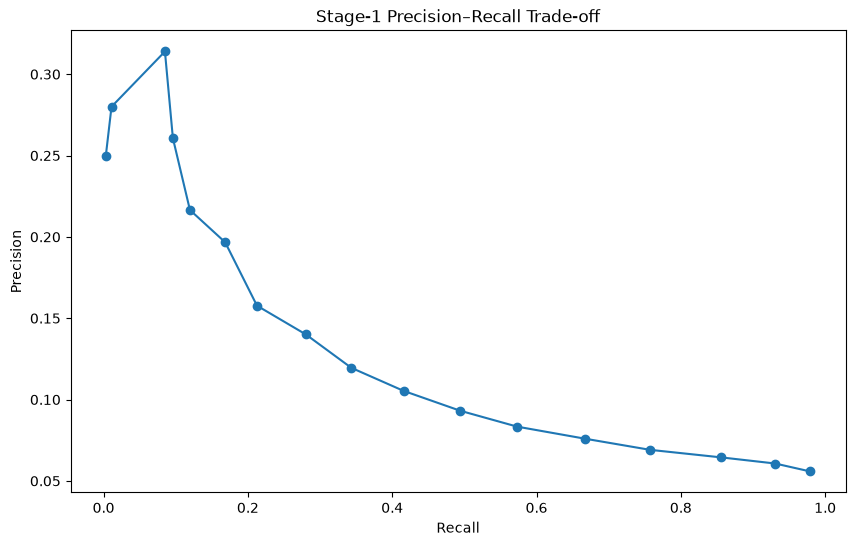

In [10]:
## Precision-Recall Trade-Off
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["recall"],
    threshold_results["precision"],
    marker="o"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Stage-1 Precision–Recall Trade-off")
plt.show()

##### Stage-1 Feature Set Expansion
### Add Intake Metadata

Now we test whether operational metadata adds signal beyond narrative.

Candidate metadata:

- Company
- State
- Date received

Product-related taxonomy is deliberately excluded from this first comparison
until its intake availability is confirmed.

This lets us answer:

> Is the delay signal actually present in the complaint narrative,
> or is it mainly organizational/process metadata?

In [11]:
## Simple Metadata Representation
from scipy.sparse import hstack

company_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=2,
    max_features=30_000
)

X_train_company = company_vectorizer.fit_transform(
    train["Company"].fillna("")
)

X_val_company = company_vectorizer.transform(
    val["Company"].fillna("")
)

X_train_combined = hstack([
    X_train_word,
    X_train_company
])

X_val_combined = hstack([
    X_val_word,
    X_val_company
])

print(X_train_combined.shape)

(57362, 119769)


In [12]:
stage1_combined_model = LogisticRegression(
    C=1,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

stage1_combined_model.fit(
    X_train_combined,
    y_train
)

val_prob_combined = (
    stage1_combined_model
    .predict_proba(X_val_combined)[:, 1]
)

val_pred_combined = (
    val_prob_combined >= 0.5
).astype(int)

combined_metrics = {
    "Accuracy": accuracy_score(y_val, val_pred_combined),
    "Precision": precision_score(
        y_val, val_pred_combined, zero_division=0
    ),
    "Recall": recall_score(
        y_val, val_pred_combined, zero_division=0
    ),
    "F1": f1_score(
        y_val, val_pred_combined, zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_val, val_prob_combined
    ),
    "PR_AUC": average_precision_score(
        y_val, val_prob_combined
    )
}

pd.Series(combined_metrics)

Accuracy     0.842405
Precision    0.139135
Recall       0.395276
F1           0.205822
ROC_AUC      0.722393
PR_AUC       0.229154
dtype: float64

##### Stage-1 Error Matrix
#### Stage-1 Operational Error Types

             Actual
             No       Yes

Pred No      TN       FN
Pred Yes     FP       TP

#### FN
A truly delayed complaint was not flagged.

Operational consequence:- missed risky/backlogged complaint.

#### FP
A complaint predicted as delayed but actually processed normally.

Operational consequence:
    unnecessary investigation / monitoring / escalation.

Therefore threshold selection should eventually depend on:

    Cost(FN) vs Cost(FP)

not merely maximum F1.

In [13]:
cm = confusion_matrix(
    y_val,
    val_pred_combined
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Not Delayed", "Actual Delayed"],
    columns=["Predicted Not Delayed", "Predicted Delayed"]
)

display(cm_df)

,Predicted Not Delayed,Predicted Delayed
Actual Not Delayed,10103,1553
Actual Delayed,384,251


##### Company Robustness
#### Stage-1 Generalization by Company

Because Company is potentially powerful, evaluate:

1. Seen-company validation rows
2. Unseen-company validation rows

> A model that performs well only when it recognizes the company
may have limited generalization to new organizations.

In [14]:
seen_companies = set(train["Company"].dropna().unique())

seen_mask = val["Company"].isin(seen_companies)

for label, mask in [
    ("Seen companies", seen_mask),
    ("Unseen companies", ~seen_mask)
]:
    if mask.sum() == 0:
        continue

    y_true = y_val[mask]
    y_pred = val_pred_combined[mask]

    print(f"\n{label}")
    print("Rows:", mask.sum())
    print("Precision:",
          precision_score(y_true, y_pred, zero_division=0))
    print("Recall:",
          recall_score(y_true, y_pred, zero_division=0))
    print("F1:",
          f1_score(y_true, y_pred, zero_division=0))


Seen companies
Rows: 12142
Precision: 0.13665315576143602
Recall: 0.383739837398374
F1: 0.20153714773697695

Unseen companies
Rows: 149
Precision: 0.19480519480519481
Recall: 0.75
F1: 0.30927835051546393


##### Decision Gate 2 — Stage-1 Classifier

We should NOT select the classifier using accuracy alone.

The candidate must be judged using:

#### Statistical performance
- PR-AUC
- Recall
- Precision
- F1

#### Operational performance
- How many delayed cases are captured?
- How many normal cases are unnecessarily flagged?
- Is the model useful for prioritization?

#### Robustness
- Seen vs unseen companies
- Temporal validation
- Rare positive-class stability

#### Decision

If the classifier provides meaningful delayed-case detection:  → continue to Stage 2

If not:  → reconsider features / target threshold / modeling formulation

##### Phase 09 — Stage-2 Conditional Regression

Stage 2 answers:

> Given that a complaint is delayed, how long will the delay be?

This is intentionally different from the original regression problem.

We no longer force the model to simultaneously learn:

    near-zero delay
    +
    multi-day delay
    +
    extreme delay

Instead, Stage 2 sees only the delayed population.

Target:-  triage_delay_days

Training population:-  triage_delay_days > 7

In [15]:
## Build Delayed-Only Training/Validation Data
train_delayed = train[
    train["triage_delay_days"] > PRIMARY_THRESHOLD
].copy()

val_delayed = val[
    val["triage_delay_days"] > PRIMARY_THRESHOLD
].copy()

print("Delayed train:", train_delayed.shape)
print("Delayed validation:", val_delayed.shape)

Delayed train: (3934, 18)
Delayed validation: (635, 18)


##### The Stage-2 Target Distribution is still right-skewed.

Therefore we compare:

1. Raw duration regression
2. log1p(duration) regression

We do not assume the log target is better.

It must earn its place through validation performance.

In [16]:
y2_train_raw = train_delayed["triage_delay_days"]
y2_val_raw = val_delayed["triage_delay_days"]

y2_train_log = np.log1p(y2_train_raw)

##### Stage-2 Baseline -- Median
Before using ML, establish a delayed-only median baseline.

> This answers:- > Does the model beat simply predicting the typical delayed duration?

In [17]:
delayed_median = y2_train_raw.median()

baseline_pred = np.full(
    len(y2_val_raw),
    delayed_median
)

stage2_baseline = {
    "MAE": mean_absolute_error(
        y2_val_raw,
        baseline_pred
    ),
    "MedianAE": median_absolute_error(
        y2_val_raw,
        baseline_pred
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y2_val_raw,
            baseline_pred
        )
    ),
    "R2": r2_score(
        y2_val_raw,
        baseline_pred
    )
}

pd.Series(stage2_baseline)

MAE         16.798259
MedianAE    18.235434
RMSE        18.054110
R2          -0.939044
dtype: float64

##### Stage-2 Text Model
We start with the same core representation:- Narrative → TF-IDF

The question:

> Does the complaint narrative contain information about the duration of an already-delayed case?

In [18]:
X2_train_text = train_delayed[TEXT_COL].fillna("")
X2_val_text = val_delayed[TEXT_COL].fillna("")

stage2_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_features=100_000,
    sublinear_tf=True
)

X2_train = stage2_vectorizer.fit_transform(X2_train_text)
X2_val = stage2_vectorizer.transform(X2_val_text)

print(X2_train.shape)

(3934, 43860)


In [19]:
### Raw-Target Ridge
stage2_raw_model = Ridge(alpha=1.0)

stage2_raw_model.fit(
    X2_train,
    y2_train_raw
)

stage2_raw_pred = stage2_raw_model.predict(X2_val)

stage2_raw_metrics = {
    "MAE": mean_absolute_error(
        y2_val_raw,
        stage2_raw_pred
    ),
    "MedianAE": median_absolute_error(
        y2_val_raw,
        stage2_raw_pred
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y2_val_raw,
            stage2_raw_pred
        )
    ),
    "R2": r2_score(
        y2_val_raw,
        stage2_raw_pred
    )
}

pd.Series(stage2_raw_metrics)

MAE         16.280702
MedianAE    16.677621
RMSE        18.033932
R2          -0.934712
dtype: float64

In [20]:
## Log-Target Ridge
stage2_log_model = Ridge(alpha=1.0)

stage2_log_model.fit(
    X2_train,
    y2_train_log
)

stage2_log_pred = stage2_log_model.predict(X2_val)

stage2_log_pred_raw = np.expm1(stage2_log_pred)

stage2_log_pred_raw = np.maximum(
    stage2_log_pred_raw,
    0
)

stage2_log_metrics = {
    "MAE": mean_absolute_error(
        y2_val_raw,
        stage2_log_pred_raw
    ),
    "MedianAE": median_absolute_error(
        y2_val_raw,
        stage2_log_pred_raw
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y2_val_raw,
            stage2_log_pred_raw
        )
    ),
    "R2": r2_score(
        y2_val_raw,
        stage2_log_pred_raw
    )
}

pd.Series(stage2_log_metrics)

MAE         13.666328
MedianAE    13.638183
RMSE        15.493196
R2          -0.427965
dtype: float64

##### Stage-2 Feature Expansion: Metadata + Narrative

For delayed cases, duration may depend on operational context.

Potential intake-time variables:

- Company
- State
- ZIP
- Date received
- Narrative

> Again:- Product / Issue / Sub-issue / Tags remain conditional until their actual intake availability is verified.

In [21]:
## Add Company
stage2_company_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=2,
    max_features=30_000
)

X2_train_company = stage2_company_vectorizer.fit_transform(
    train_delayed["Company"].fillna("")
)

X2_val_company = stage2_company_vectorizer.transform(
    val_delayed["Company"].fillna("")
)

X2_train_combined = hstack([
    X2_train,
    X2_train_company
])

X2_val_combined = hstack([
    X2_val,
    X2_val_company
])

In [22]:
stage2_combined_model = Ridge(alpha=1.0)

stage2_combined_model.fit(
    X2_train_combined,
    y2_train_log
)

stage2_combined_log_pred = (
    stage2_combined_model
    .predict(X2_val_combined)
)

stage2_combined_pred = np.maximum(
    np.expm1(stage2_combined_log_pred),
    0
)

stage2_combined_metrics = {
    "MAE": mean_absolute_error(
        y2_val_raw,
        stage2_combined_pred
    ),
    "MedianAE": median_absolute_error(
        y2_val_raw,
        stage2_combined_pred
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y2_val_raw,
            stage2_combined_pred
        )
    ),
    "R2": r2_score(
        y2_val_raw,
        stage2_combined_pred
    )
}

pd.Series(stage2_combined_metrics)

MAE         12.941869
MedianAE    12.303149
RMSE        15.071877
R2          -0.351357
dtype: float64

##### Stage-2 Error By Delay Regime & Conditional Error Analysis

The delayed population itself contains:

    7–30 days
    >30 days

- These regimes may behave differently. Therefore we evaluate error separately.

In [23]:
stage2_eval = val_delayed[
    ["triage_delay_days"]
].copy()

stage2_eval["prediction"] = stage2_combined_pred

stage2_eval["absolute_error"] = (
    stage2_eval["triage_delay_days"]
    - stage2_eval["prediction"]
).abs()

stage2_eval["regime"] = pd.cut(
    stage2_eval["triage_delay_days"],
    bins=[7, 14, 30, np.inf],
    labels=["7-14d", "14-30d", ">30d"]
)

stage2_regime_metrics = (
    stage2_eval
    .groupby("regime", observed=False)
    .agg(
        count=("triage_delay_days", "size"),
        actual_mean=("triage_delay_days", "mean"),
        predicted_mean=("prediction", "mean"),
        MAE=("absolute_error", "mean")
    )
)

display(stage2_regime_metrics.round(4))

,count,actual_mean,predicted_mean,MAE
regime,,,,
7-14d,279,10.8199,26.4885,15.6686
14-30d,246,20.2379,28.3909,9.0526
>30d,110,44.8918,30.8897,14.7239


##### Stage-2 Prediction Compression Check
- A successful Stage-2 model should reduce the extreme compression
observed in Notebook 05.

We therefore compare:

    actual distribution
    predicted distribution

particularly at:

    median
    P90
    P95
    P99

In [24]:
distribution_comparison = pd.DataFrame({
    "Actual": [
        y2_val_raw.median(),
        y2_val_raw.quantile(.90),
        y2_val_raw.quantile(.95),
        y2_val_raw.quantile(.99),
        y2_val_raw.max()
    ],
    "Predicted": [
        np.median(stage2_combined_pred),
        np.quantile(stage2_combined_pred, .90),
        np.quantile(stage2_combined_pred, .95),
        np.quantile(stage2_combined_pred, .99),
        np.max(stage2_combined_pred)
    ]
}, index=["Median", "P90", "P95", "P99", "Max"])

display(distribution_comparison.round(4))

,Actual,Predicted
Median,14.7974,26.9629
P90,48.0938,36.3030
P95,49.0304,40.4234
P99,50.8409,49.3935
Max,91.8460,58.1731


##### Combine Stage-1 & Stage-2 Experiments
##### Two-Stage System

For each validation complaint:

Stage 1:-  P(delayed > 7d)

If predicted delayed:-  use Stage-2 duration estimate

Otherwise:-  predict near-immediate baseline duration

This creates a complete prediction system.

> However, there is an important design choice:-> What duration should we predict when Stage 1 says "not delayed"?

- We should NOT simply predict zero because the actual process has
small but non-zero delays.

- For the first system baseline, use the median duration among
non-delayed training cases.

In [25]:
non_delayed_median = train.loc[
    train["triage_delay_days"] <= PRIMARY_THRESHOLD,
    "triage_delay_days"
].median()

print("Non-delayed baseline:", non_delayed_median)

Non-delayed baseline: 0.0090625


In [34]:
# ============================================================
# Correct Stage-2 Prediction Generation
# Predict duration for ALL validation rows.
#
# Stage 1 will decide which rows actually use this prediction.
# ============================================================

X_val_all_text = val[TEXT_COL].fillna("")

X_val_all_text_vec = stage2_vectorizer.transform(
    X_val_all_text
)

X_val_all_company_vec = stage2_company_vectorizer.transform(
    val["Company"].fillna("")
)

X_val_all_combined = hstack([
    X_val_all_text_vec,
    X_val_all_company_vec
])

# Stage-2 model predicts log-duration
stage2_all_val_log_pred = (
    stage2_combined_model.predict(
        X_val_all_combined
    )
)

# Convert back to original days
stage2_all_val_pred = np.maximum(
    np.expm1(stage2_all_val_log_pred),
    0
)

print("Stage-2 predictions generated:", len(stage2_all_val_pred))
print("Validation rows:", len(val))

Stage-2 predictions generated: 12291
Validation rows: 12291


In [28]:
two_stage = val[
    ["triage_delay_days"]
].copy()

two_stage["stage1_delayed"] = (
    val_prob_combined >= stage1_threshold
)

two_stage["stage2_prediction"] = np.nan

delayed_indices = val_delayed.index

two_stage.loc[
    delayed_indices,
    "stage2_prediction"
] = stage2_combined_pred

two_stage["final_prediction"] = np.where(
    two_stage["stage1_delayed"],
    two_stage["stage2_prediction"],
    non_delayed_median
)

two_stage["final_prediction"] = (
    two_stage["final_prediction"]
    .fillna(non_delayed_median)
)

display(two_stage.head())

,triage_delay_days,stage1_delayed,stage2_prediction,final_prediction
57362,0.044167,False,NaN,0.009062
57363,0.023519,False,NaN,0.009062
57364,0.009433,False,NaN,0.009062
57365,0.001968,False,NaN,0.009062
57366,0.022315,False,NaN,0.009062


In [35]:
# ============================================================
# Two-Stage Deployment-Style Prediction
# ============================================================

stage1_threshold = 0.50

# Stage 1 decision for EVERY validation complaint
stage1_decision = (
    val_prob_combined >= stage1_threshold
)

# Baseline prediction for cases considered non-delayed
non_delayed_median = train.loc[
    train["triage_delay_days"] <= PRIMARY_THRESHOLD,
    "triage_delay_days"
].median()

# Final two-stage prediction
two_stage_pred = np.where(
    stage1_decision,
    stage2_all_val_pred,
    non_delayed_median
)

# Build evaluation dataframe
two_stage = val[
    ["triage_delay_days", "Company"]
].copy()

two_stage["stage1_probability"] = val_prob_combined
two_stage["stage1_delayed"] = stage1_decision

two_stage["stage2_prediction"] = stage2_all_val_pred

two_stage["final_prediction"] = two_stage_pred

two_stage["absolute_error"] = (
    two_stage["triage_delay_days"]
    - two_stage["final_prediction"]
).abs()

display(two_stage.head())

,triage_delay_days,Company,stage1_probability,stage1_delayed,stage2_prediction,final_prediction,absolute_error
57362,0.044167,AMERICAN EXPRESS COMPANY,0.183371,False,27.750836,0.009062,0.035104
57363,0.023519,"CAINE & WEINER COMPANY, INC.",0.180095,False,21.806352,0.009062,0.014456
57364,0.009433,Resurgent Capital Services L.P.,0.178540,False,27.065836,0.009062,0.000370
57365,0.001968,"Bilt Technologies, Inc.",0.137789,False,21.509680,0.009062,0.007095
57366,0.022315,Chime Financial Inc,0.172992,False,34.306127,0.009062,0.013252


In [36]:
# ============================================================
# Correct Two-Stage Evaluation
# ============================================================

y_two_stage = two_stage["triage_delay_days"]
pred_two_stage = two_stage["final_prediction"]

two_stage_metrics = {
    "MAE": mean_absolute_error(
        y_two_stage,
        pred_two_stage
    ),
    "MedianAE": median_absolute_error(
        y_two_stage,
        pred_two_stage
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y_two_stage,
            pred_two_stage
        )
    ),
    "R2": r2_score(
        y_two_stage,
        pred_two_stage
    )
}

pd.Series(two_stage_metrics)

MAE          4.428886
MedianAE     0.006424
RMSE        11.200580
R2          -3.309497
dtype: float64

##### But overall MAE is not enough

This is a critical expert point.

> If the two-stage system improves overall MAE only by becoming better at the enormous immediate population, that does not necessarily solve the business problem.

> We therefore compare:

Overall MAE
MAE ≤7d
MAE >7d
MAE >14d
MAE >30d

> and Stage-1:

Recall >7d
Precision >7d
PR-AUC

In [37]:
# ============================================================
# Two-Stage Error by Actual Delay Regime
# ============================================================

regime_rows = []

regimes = {
    "<=7d": two_stage["triage_delay_days"] <= 7,
    ">7d": two_stage["triage_delay_days"] > 7,
    ">14d": two_stage["triage_delay_days"] > 14,
    ">30d": two_stage["triage_delay_days"] > 30
}

for regime_name, mask in regimes.items():

    if mask.sum() == 0:
        continue

    errors = two_stage.loc[mask, "absolute_error"]

    regime_rows.append({
        "regime": regime_name,
        "n": mask.sum(),
        "percentage": mask.mean() * 100,
        "MAE": errors.mean(),
        "MedianAE": errors.median(),
        "RMSE": np.sqrt(
            np.mean(errors ** 2)
        )
    })

two_stage_regime_metrics = pd.DataFrame(
    regime_rows
)

display(
    two_stage_regime_metrics.round(4)
)

,regime,n,percentage,MAE,MedianAE,RMSE
0,<=7d,11656,94.8336,3.7333,0.0060,10.4421
1,>7d,635,5.1664,17.1966,14.0097,20.6585
2,>14d,356,2.8964,20.6567,18.8349,24.7980
3,>30d,110,0.8950,30.6892,31.8747,35.6651


In [38]:
## Stage-1 Operating Threshold
# ============================================================
# Stage-1 Threshold Candidates
# ============================================================

stage1_threshold_table = []

for threshold in np.arange(0.10, 0.91, 0.05):

    pred = (
        val_prob_combined >= threshold
    ).astype(int)

    stage1_threshold_table.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(
            y_val,
            pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_val,
            pred,
            zero_division=0
        ),
        "flag_rate": pred.mean()
    })

stage1_threshold_table = pd.DataFrame(
    stage1_threshold_table
)

display(
    stage1_threshold_table.round(4)
)

,threshold,precision,recall,f1,flag_rate
0,0.10,0.0594,0.9543,0.1118,0.8304
1,0.15,0.0677,0.9087,0.1261,0.6931
2,0.20,0.0760,0.8331,0.1393,0.5664
3,0.25,0.0829,0.7291,0.1489,0.4542
4,0.30,0.0909,0.6394,0.1592,0.3634
5,0.35,0.1007,0.5717,0.1712,0.2934
6,0.40,0.1115,0.5024,0.1824,0.2329
7,0.45,0.1214,0.4346,0.1898,0.1849
8,0.50,0.1391,0.3953,0.2058,0.1468
9,0.55,0.1633,0.3638,0.2254,0.1151


##### Delayed Threshold Sensitivity

Repeat Stage-1 classification conceptually for:

>1 day
>3 days
>7 days
>14 days
>30 days

The purpose is not to train five final systems immediately.

The purpose is to determine whether the modeling formulation is robust
to reasonable definitions of "delayed".

A threshold that:

- has too few positives
- changes dramatically across time
- cannot be predicted
- produces unusable precision/recall

> should not become the primary operational definition.

In [39]:
threshold_sensitivity = []

for threshold in [1, 3, 7, 14, 30]:

    y_train_t = (
        train["triage_delay_days"] > threshold
    ).astype(int)

    y_val_t = (
        val["triage_delay_days"] > threshold
    ).astype(int)

    threshold_sensitivity.append({
        "threshold": threshold,
        "train_positive_n": y_train_t.sum(),
        "train_positive_%": y_train_t.mean() * 100,
        "validation_positive_n": y_val_t.sum(),
        "validation_positive_%": y_val_t.mean() * 100
    })

threshold_sensitivity = pd.DataFrame(
    threshold_sensitivity
)

display(threshold_sensitivity.round(3))

,threshold,train_positive_n,train_positive_%,validation_positive_n,validation_positive_%
0,1,4269,7.442,712,5.793
1,3,4169,7.268,699,5.687
2,7,3934,6.858,635,5.166
3,14,3316,5.781,356,2.896
4,30,2123,3.701,110,0.895


##### Final Model Comparison

The comparison must preserve the distinction between:

#### One-stage regression

Predict exact latency directly.

#### Two-stage system

First predict delayed risk. Then predict duration conditional on delayed regime.

The purpose is NOT to declare:- two-stage = automatically better

Instead:

> Does the two-stage structure solve the specific failure identified
> in Notebook 05?

In [40]:
## The one-stage numbers above are the frozen Notebook 05 diagnostic benchmark
model_comparison = pd.DataFrame([
    {
        "model": "One-stage Ridge log1p",
        "MAE": 1.373852,
        "MedianAE": 0.212139,
        "RMSE": 5.364362,
        "R2": 0.011412
    },
    {
        "model": "Two-stage system",
        "MAE": two_stage_metrics["MAE"],
        "MedianAE": two_stage_metrics["MedianAE"],
        "RMSE": two_stage_metrics["RMSE"],
        "R2": two_stage_metrics["R2"]
    }
])

display(model_comparison.round(4))

,model,MAE,MedianAE,RMSE,R2
0,One-stage Ridge log1p,1.3739,0.2121,5.3644,0.0114
1,Two-stage system,4.4289,0.0064,11.2006,-3.3095


##### Analysis Insights

##### 1. Delayed-Regime Definition

The triage process contains a dominant near-immediate regime and
a much smaller delayed regime.

A >7-day threshold provides a practical experimental definition because
it retains thousands of training examples and hundreds of validation examples.

However, >7 days is a modeling/business candidate rather than an intrinsic
truth about the dataset.

---

##### 2. Stage-1 Classification

The Stage-1 model should be evaluated primarily on its ability to identify
true delayed complaints.

Accuracy is insufficient because the delayed class is rare.

The key measures are:

- PR-AUC
- Recall
- Precision
- F1

> The preferred operating threshold should depend on the relative business
cost of missed delays versus unnecessary alerts.

---

##### 3. Stage-2 Regression

Stage 2 is trained only on genuinely delayed complaints.

This removes the enormous near-zero population from the duration-learning problem.

- The central question is whether the conditional model can better represent
the 7+ day regime than the original one-stage regression.

---

##### 4. Two-Stage System

The complete system should be judged on two dimensions:

##### Detection

Can we identify delayed cases?

##### Duration estimation

Once a case is considered delayed, can we estimate how long it may take?

A system that has good duration MAE but poor delayed-case recall is not
operationally useful for early intervention.

Likewise, a classifier with high recall but excessive false positives
may create investigator workload.

---

##### 5. Business Trade-off

The real decision is not:- "Which model has the lowest MAE?"

It is:- "Which errors are expensive?"

Potential costs:
False Negative:
    delayed complaint is missed.

False Positive:
    normal complaint is unnecessarily flagged.

Duration error:
    predicted resolution/triage time differs from actual process time.

Therefore, future deployment should consider an explicit cost matrix.

---

##### 6. Robustness

Company is potentially useful but can create memorization risk.

Therefore, performance should eventually be reported separately for:

- seen companies
- unseen companies

Temporal drift must also be monitored because the prevalence of long delays
changed substantially across the six-month period.

---

##### 7. Test Set

The test set remains frozen.

The dramatically lower test-period delayed prevalence means that final test
performance must be interpreted alongside the test-period population.

A good test score alone cannot establish that the model learned rare
long-delay behavior.

---

##### 8. Final Modeling Decision

If the two-stage system:

1. materially improves delayed-case detection,
2. provides useful conditional duration estimates,
3. does not create excessive false-positive workload,
4. remains reasonably robust across companies and temporal regimes,

then the two-stage/hurdle formulation becomes the preferred architecture.

Otherwise, return to feature engineering/model formulation rather than
blindly increasing model complexity.

---

##### Final Mental Model

Original problem:

    Complaint → Exact delay

Observed reality:

    Complaint
        ↓
    Operational regime
      /        \
    Normal    Delayed
      ↓          ↓
   minutes    days/weeks
                ↓
             duration

Therefore:

    Stage 1 = regime detection

    Stage 2 = conditional duration estimation

> This architecture is justified only if validation evidence supports it.

##### Project 2 — Two-Stage Evaluation & Model Selection

##### Phases 10–11

- This notebook evaluates whether the two-stage architecture is genuinely
better suited to the CFPB triage-latency problem than the original
one-stage regression.

Two-stage system evaluation:-  Which behavior is actually useful?
Model selection:-  Which exact configuration should become final?

##### One-stage system

Complaint:-  Exact latency prediction

##### Two-stage system

Complaint
   ↓
Delayed-risk classifier
   ↓
If delayed → conditional duration regression
   ↓
Final latency estimate

---

##### Frozen Evaluation Rules

1. Test remains completely frozen.
2. Validation is used for model/threshold selection.
3. Test is used only after final selection.
4. No post-intake features.
5. No outlier removal.
6. No leakage from actual validation/test targets into predictions.
7. Stage-2 predictions must be generated for every row that Stage 1
   could potentially route to Stage 2.

##### Model Candidates

We compare:

##### Candidate A
Original one-stage Ridge log1p model.

##### Candidate B
Two-stage system:

- Stage 1:- delayed > 7 days classifier

- Stage 2:- delayed-only duration regression

##### Baseline:-  Train non-delayed median.

> The purpose is to determine whether the two-stage architecture
actually addresses the failure discovered in Notebook 05.

In [42]:
ONE_STAGE_METRICS = {
    "MAE": 1.373852,
    "MedianAE": 0.212139,
    "RMSE": 5.364362,
    "R2": 0.011412
}

print("One-stage benchmark:")
display(pd.Series(ONE_STAGE_METRICS))

One-stage benchmark:


MAE        1.3739
MedianAE   0.2121
RMSE       5.3644
R2         0.0114
dtype: float64

##### Stage-1 Evaluation

> Primary question:-> How well can the system identify complaints likely to experience a >7-day triage delay?

Primary metrics:

- PR-AUC
- Recall
- Precision
- F1

Operational metric:-  Flag rate

A classifier with 95% recall but a 70% flag rate may be operationally
unacceptable because it creates excessive workload.

- Therefore classification quality and workload must be evaluated together.

In [43]:
stage1_operating_points = []

for threshold in np.arange(0.10, 0.91, 0.05):

    pred = (
        val_prob_combined >= threshold
    ).astype(int)

    stage1_operating_points.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(
            y_val, pred, zero_division=0
        ),
        "recall": recall_score(
            y_val, pred, zero_division=0
        ),
        "f1": f1_score(
            y_val, pred, zero_division=0
        ),
        "flag_rate": pred.mean() * 100
    })

stage1_operating_points = pd.DataFrame(
    stage1_operating_points
)

display(
    stage1_operating_points.round(4)
)

,threshold,precision,recall,f1,flag_rate
0,0.1000,0.0594,0.9543,0.1118,83.0364
1,0.1500,0.0677,0.9087,0.1261,69.3109
2,0.2000,0.0760,0.8331,0.1393,56.6431
3,0.2500,0.0829,0.7291,0.1489,45.4153
4,0.3000,0.0909,0.6394,0.1592,36.3355
5,0.3500,0.1007,0.5717,0.1712,29.3385
6,0.4000,0.1115,0.5024,0.1824,23.2853
7,0.4500,0.1214,0.4346,0.1898,18.4932
8,0.5000,0.1391,0.3953,0.2058,14.6774
9,0.5500,0.1633,0.3638,0.2254,11.5125


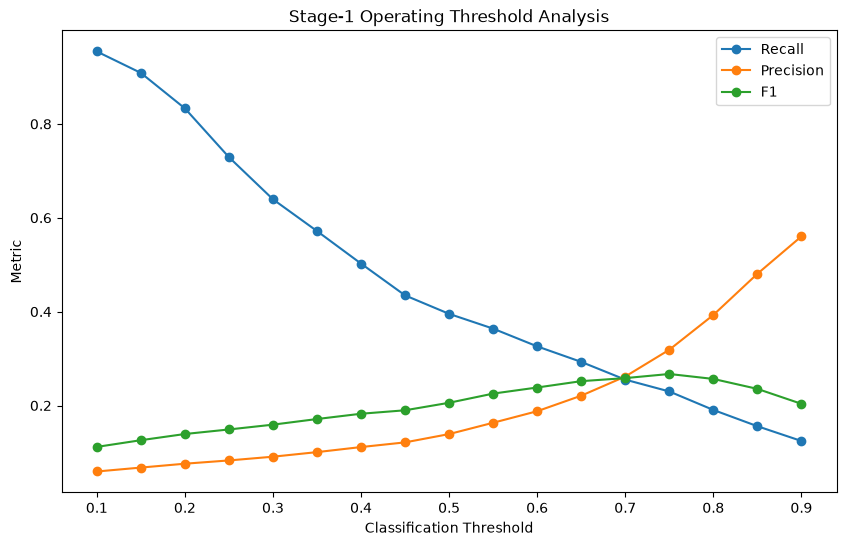

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(
    stage1_operating_points["threshold"],
    stage1_operating_points["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    stage1_operating_points["threshold"],
    stage1_operating_points["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    stage1_operating_points["threshold"],
    stage1_operating_points["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Metric")
plt.title("Stage-1 Operating Threshold Analysis")
plt.legend()
plt.show()

##### Stage-1 Selection Rule

Do not automatically choose the threshold with maximum F1.

For an operational delay-risk system:-  FN = missed delayed complaint

may be more expensive than:-  FP = unnecessary flagged complaint

Therefore the final threshold should be selected based on a reasonable
precision/recall/workload trade-off.

- For this development stage, retain several candidate operating points
rather than pretending that 0.50 is universally correct.

In [45]:
# Candidate operating points for comparison

candidate_stage1_thresholds = [
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65
]

candidate_rows = []

for threshold in candidate_stage1_thresholds:

    pred = (
        val_prob_combined >= threshold
    ).astype(int)

    candidate_rows.append({
        "threshold": threshold,
        "precision": precision_score(
            y_val, pred, zero_division=0
        ),
        "recall": recall_score(
            y_val, pred, zero_division=0
        ),
        "f1": f1_score(
            y_val, pred, zero_division=0
        ),
        "flag_rate_%": pred.mean() * 100
    })

candidate_stage1_table = pd.DataFrame(candidate_rows)

display(
    candidate_stage1_table.round(4)
)

,threshold,precision,recall,f1,flag_rate_%
0,0.4000,0.1115,0.5024,0.1824,23.2853
1,0.4500,0.1214,0.4346,0.1898,18.4932
2,0.5000,0.1391,0.3953,0.2058,14.6774
3,0.5500,0.1633,0.3638,0.2254,11.5125
4,0.6000,0.1878,0.3260,0.2383,8.9659
5,0.6500,0.2209,0.2929,0.2519,6.8505


##### Stage-2 Evaluation

Stage 2 is evaluated on the TRUE delayed validation population.

This answers:

> Once a complaint actually belongs to the delayed regime,
> how accurately can we estimate its duration?

Primary metrics:

- MAE
- Median Absolute Error

Secondary:

- RMSE
- R²

> Tail behavior is separately evaluated because operational delays
are strongly right-skewed.

In [46]:
stage2_metrics = {
    "MAE": mean_absolute_error(
        y2_val_raw,
        stage2_combined_pred
    ),
    "MedianAE": median_absolute_error(
        y2_val_raw,
        stage2_combined_pred
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y2_val_raw,
            stage2_combined_pred
        )
    ),
    "R2": r2_score(
        y2_val_raw,
        stage2_combined_pred
    )
}

display(pd.Series(stage2_metrics))

MAE        12.9419
MedianAE   12.3031
RMSE       15.0719
R2         -0.3514
dtype: float64

##### Stage-2 Tail Evaluation

The most important question is:

> Does Stage 2 actually improve estimation of the long-delay regime?

Evaluate:

- 7+ days
- 14+ days
- 30+ days

> Do not remove the >30-day cases merely because they are rare.
They represent genuine operational outcomes in the historical process.

In [47]:
stage2_tail_rows = []

for threshold in [7, 14, 30]:

    mask = (
        y2_val_raw > threshold
    )

    if mask.sum() == 0:
        continue

    actual = y2_val_raw[mask]
    pred = stage2_combined_pred[mask]

    stage2_tail_rows.append({
        "threshold": threshold,
        "n": mask.sum(),
        "actual_mean": actual.mean(),
        "predicted_mean": pred.mean(),
        "MAE": mean_absolute_error(actual, pred),
        "MedianAE": median_absolute_error(actual, pred),
        "RMSE": np.sqrt(
            mean_squared_error(actual, pred)
        )
    })

stage2_tail_table = pd.DataFrame(
    stage2_tail_rows
)

display(stage2_tail_table.round(4))

,threshold,n,actual_mean,predicted_mean,MAE,MedianAE,RMSE
0,7,635,20.3707,27.9879,12.9419,12.3031,15.0719
1,14,356,27.8557,29.1630,10.8049,8.8997,13.6082
2,30,110,44.8918,30.8897,14.7239,15.2574,17.4489


##### Full Two-Stage System

The system must now be evaluated exactly as it would operate:

1. Stage 1 receives every validation complaint.
2. Stage 1 outputs delayed/not-delayed.
3. If Stage 1 predicts delayed:
       Stage 2 prediction is used.
4. Otherwise:
       non-delayed baseline is used.

IMPORTANT:

Stage 2 predictions are generated for ALL validation complaints.

We must never use:

    actual delayed status

to decide whether Stage 2 gets applied.

> That would create target leakage during evaluation.

In [48]:
# ============================================================
# Function for deployment-style two-stage prediction
# ============================================================

def build_two_stage_predictions(
    stage1_probabilities,
    stage2_predictions,
    non_delayed_baseline,
    threshold
):

    stage1_flag = (
        stage1_probabilities >= threshold
    )

    final_prediction = np.where(
        stage1_flag,
        stage2_predictions,
        non_delayed_baseline
    )

    return stage1_flag, final_prediction

In [49]:
# Verify aligned lengths

assert len(val_prob_combined) == len(val)
assert len(stage2_all_val_pred) == len(val)

print("Alignment verified.")

Alignment verified.


In [50]:
# Build two-stage predictions at 0.50

stage1_flag, final_pred = build_two_stage_predictions(
    stage1_probabilities=val_prob_combined,
    stage2_predictions=stage2_all_val_pred,
    non_delayed_baseline=non_delayed_median,
    threshold=0.50
)

two_stage_eval = pd.DataFrame({
    "actual_delay": val["triage_delay_days"].values,
    "stage1_probability": val_prob_combined,
    "stage1_flag": stage1_flag,
    "stage2_prediction": stage2_all_val_pred,
    "final_prediction": final_pred
})

two_stage_eval["absolute_error"] = (
    two_stage_eval["actual_delay"]
    - two_stage_eval["final_prediction"]
).abs()

display(two_stage_eval.head())

,actual_delay,stage1_probability,stage1_flag,stage2_prediction,final_prediction,absolute_error
0,0.0442,0.1834,False,27.7508,0.0091,0.0351
1,0.0235,0.1801,False,21.8064,0.0091,0.0145
2,0.0094,0.1785,False,27.0658,0.0091,0.0004
3,0.0020,0.1378,False,21.5097,0.0091,0.0071
4,0.0223,0.1730,False,34.3061,0.0091,0.0133


In [51]:
def regression_metrics(actual, predicted):

    return {
        "MAE": mean_absolute_error(
            actual, predicted
        ),
        "MedianAE": median_absolute_error(
            actual, predicted
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual, predicted
            )
        ),
        "R2": r2_score(
            actual, predicted
        )
    }


two_stage_metrics = regression_metrics(
    two_stage_eval["actual_delay"],
    two_stage_eval["final_prediction"]
)

display(pd.Series(two_stage_metrics))

MAE         4.4289
MedianAE    0.0064
RMSE       11.2006
R2         -3.3095
dtype: float64

In [52]:
## Two-Stage Error By Actual Regime
two_stage_regime_rows = []

regime_conditions = {
    "<=7d": two_stage_eval["actual_delay"] <= 7,
    ">7d": two_stage_eval["actual_delay"] > 7,
    ">14d": two_stage_eval["actual_delay"] > 14,
    ">30d": two_stage_eval["actual_delay"] > 30
}

for regime, mask in regime_conditions.items():

    actual = two_stage_eval.loc[
        mask, "actual_delay"
    ]

    pred = two_stage_eval.loc[
        mask, "final_prediction"
    ]

    two_stage_regime_rows.append({
        "regime": regime,
        "n": len(actual),
        "percentage": len(actual) / len(two_stage_eval) * 100,
        "MAE": mean_absolute_error(actual, pred),
        "MedianAE": median_absolute_error(actual, pred),
        "RMSE": np.sqrt(
            mean_squared_error(actual, pred)
        )
    })

two_stage_regime_table = pd.DataFrame(
    two_stage_regime_rows
)

display(
    two_stage_regime_table.round(4)
)

,regime,n,percentage,MAE,MedianAE,RMSE
0,<=7d,11656,94.8336,3.7333,0.0060,10.4421
1,>7d,635,5.1664,17.1966,14.0097,20.6585
2,>14d,356,2.8964,20.6567,18.8349,24.7980
3,>30d,110,0.8950,30.6892,31.8747,35.6651


##### Two-Stage Detection + Duration Matrix

A two-stage model can fail in different ways.

##### Type 1
Stage 1 misses the delayed complaint.

→ Stage 2 never gets activated.

##### Type 2
Stage 1 correctly detects delay, but Stage 2 estimates the duration poorly.

##### Type 3
Stage 1 falsely flags a normal complaint.

→ Stage 2 generates an unnecessary duration estimate.

- Therefore the system must be analyzed as two linked components,
not as one single MAE number.

In [53]:
actual_delayed = (
    two_stage_eval["actual_delay"] > PRIMARY_THRESHOLD
)

predicted_delayed = (
    two_stage_eval["stage1_flag"]
)

detection_confusion = confusion_matrix(
    actual_delayed,
    predicted_delayed
)

detection_table = pd.DataFrame(
    detection_confusion,
    index=[
        "Actual Not Delayed",
        "Actual Delayed"
    ],
    columns=[
        "Predicted Not Delayed",
        "Predicted Delayed"
    ]
)

display(detection_table)

,Predicted Not Delayed,Predicted Delayed
Actual Not Delayed,10103,1553
Actual Delayed,384,251


In [54]:
stage1_system_metrics = {
    "Precision": precision_score(
        actual_delayed,
        predicted_delayed,
        zero_division=0
    ),
    "Recall": recall_score(
        actual_delayed,
        predicted_delayed,
        zero_division=0
    ),
    "F1": f1_score(
        actual_delayed,
        predicted_delayed,
        zero_division=0
    ),
    "PR_AUC": average_precision_score(
        actual_delayed,
        two_stage_eval["stage1_probability"]
    ),
    "ROC_AUC": roc_auc_score(
        actual_delayed,
        two_stage_eval["stage1_probability"]
    )
}

display(pd.Series(stage1_system_metrics))

Precision   0.1391
Recall      0.3953
F1          0.2058
PR_AUC      0.2292
ROC_AUC     0.7224
dtype: float64

##### Threshold Sensitivity of the Complete Two-Stage System

The classification threshold affects the final regression system.

- Lower threshold:

    more cases → Stage 2
    ↑ recall
    ↑ false positives
    potentially ↑ workload

- Higher threshold:

    fewer cases → Stage 2
    ↓ workload
    ↓ delayed-case recall
    potentially more missed long delays

> Therefore evaluate the complete system across candidate thresholds.

In [55]:
system_threshold_rows = []

for threshold in np.arange(0.20, 0.81, 0.05):

    flag, prediction = build_two_stage_predictions(
        stage1_probabilities=val_prob_combined,
        stage2_predictions=stage2_all_val_pred,
        non_delayed_baseline=non_delayed_median,
        threshold=threshold
    )

    actual = val["triage_delay_days"].values

    delayed_actual = (
        actual > PRIMARY_THRESHOLD
    )

    system_threshold_rows.append({
        "threshold": round(threshold, 2),
        "flag_rate_%": flag.mean() * 100,
        "delayed_recall": recall_score(
            delayed_actual,
            flag,
            zero_division=0
        ),
        "delayed_precision": precision_score(
            delayed_actual,
            flag,
            zero_division=0
        ),
        "overall_MAE": mean_absolute_error(
            actual,
            prediction
        ),
        "overall_MedianAE": median_absolute_error(
            actual,
            prediction
        ),
        "overall_RMSE": np.sqrt(
            mean_squared_error(
                actual,
                prediction
            )
        )
    })

system_threshold_table = pd.DataFrame(
    system_threshold_rows
)

display(
    system_threshold_table.round(4)
)

,threshold,flag_rate_%,delayed_recall,delayed_precision,overall_MAE,overall_MedianAE,overall_RMSE
0,0.2000,56.6431,0.8331,0.0760,15.0467,19.6615,20.6052
1,0.2500,45.4153,0.7291,0.0829,12.1692,0.0235,18.5178
2,0.3000,36.3355,0.6394,0.0909,9.8765,0.0100,16.7073
3,0.3500,29.3385,0.5717,0.1007,8.1004,0.0080,15.1293
4,0.4000,23.2853,0.5024,0.1115,6.5893,0.0072,13.6588
5,0.4500,18.4932,0.4346,0.1214,5.4039,0.0068,12.3751
6,0.5000,14.6774,0.3953,0.1391,4.4289,0.0064,11.2006
7,0.5500,11.5125,0.3638,0.1633,3.6300,0.0062,10.1425
8,0.6000,8.9659,0.3260,0.1878,3.0067,0.0060,9.2340
9,0.6500,6.8505,0.2929,0.2209,2.4854,0.0058,8.3912


##### Business Workload Analysis

Flag rate is important.

If:- 10% of complaints are flagged

the operational team receives approximately:-  10 flagged cases per 100 complaints.

If:-  50% are flagged

the model may become operationally expensive even with excellent recall.

- Therefore:- Detection performance + Flagging workload + Missed-delay risk

> must be considered together.

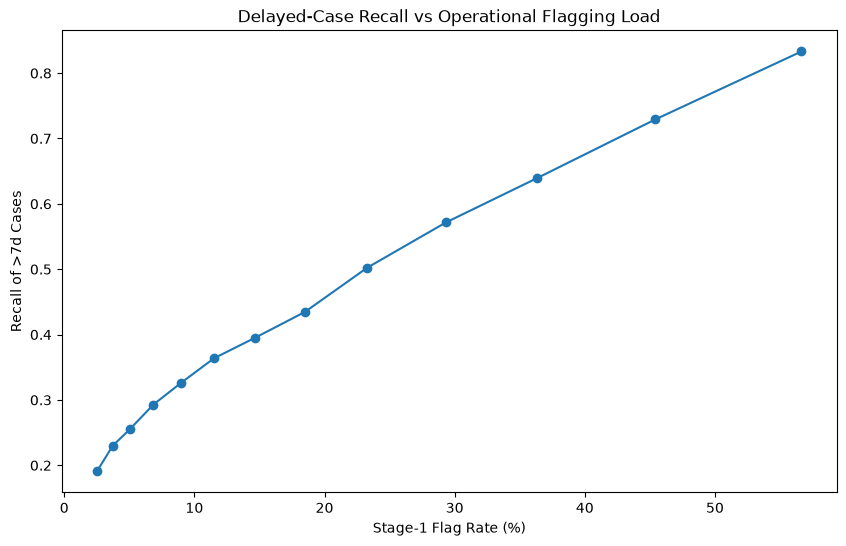

In [56]:
plt.figure(figsize=(10, 6))

plt.plot(
    system_threshold_table["flag_rate_%"],
    system_threshold_table["delayed_recall"],
    marker="o"
)

plt.xlabel("Stage-1 Flag Rate (%)")
plt.ylabel("Recall of >7d Cases")
plt.title("Delayed-Case Recall vs Operational Flagging Load")
plt.show()

##### One-Stage vs Two-Stage Comparison

The comparison must answer:

##### One-stage model
How well does direct regression predict latency?

##### Two-stage model
How well does the architecture:- detect delayed cases + estimate duration

- solve the specific failure identified in Notebook 05?

In [57]:
comparison_rows = [
    {
        "model": "One-stage Ridge log1p",
        "MAE": ONE_STAGE_METRICS["MAE"],
        "MedianAE": ONE_STAGE_METRICS["MedianAE"],
        "RMSE": ONE_STAGE_METRICS["RMSE"],
        "R2": ONE_STAGE_METRICS["R2"]
    },
    {
        "model": "Two-stage system",
        "MAE": two_stage_metrics["MAE"],
        "MedianAE": two_stage_metrics["MedianAE"],
        "RMSE": two_stage_metrics["RMSE"],
        "R2": two_stage_metrics["R2"]
    }
]

model_comparison = pd.DataFrame(
    comparison_rows
)

display(
    model_comparison.round(4)
)

,model,MAE,MedianAE,RMSE,R2
0,One-stage Ridge log1p,1.3739,0.2121,5.3644,0.0114
1,Two-stage system,4.4289,0.0064,11.2006,-3.3095


##### Tail Comparison

Overall MAE can hide the exact problem we care about.

Compare the one-stage and two-stage systems for:

- >1 day
- >7 days
- >14 days
- >30 days

> The purpose is to determine whether the two-stage architecture
actually improves the delayed regime.

In [58]:
tail_comparison_rows = []

for threshold in [1, 7, 14, 30]:

    mask = (
        val["triage_delay_days"].values > threshold
    )

    actual = val.loc[
        mask, "triage_delay_days"
    ].values

    one_stage_pred = None

    # Notebook 05 prediction should be loaded/recreated here
    # if available.
    #
    # For now, evaluate the two-stage system.

    two_stage_pred_tail = two_stage_eval.loc[
        mask, "final_prediction"
    ].values

    tail_comparison_rows.append({
        "threshold": threshold,
        "n": mask.sum(),
        "two_stage_MAE": mean_absolute_error(
            actual,
            two_stage_pred_tail
        ),
        "two_stage_MedianAE": median_absolute_error(
            actual,
            two_stage_pred_tail
        )
    })

tail_comparison = pd.DataFrame(
    tail_comparison_rows
)

display(
    tail_comparison.round(4)
)

,threshold,n,two_stage_MAE,two_stage_MedianAE
0,1,712,16.6495,13.9380
1,7,635,17.1966,14.0097
2,14,356,20.6567,18.8349
3,30,110,30.6892,31.8747


#### Model Selection Criteria

The final model is NOT selected using one metric.

#### Primary

1. Delayed-case recall
2. PR-AUC
3. Operational flag rate
4. Overall MAE
5. Tail MAE

#### Secondary

6. Median Absolute Error
7. RMSE
8. R²
9. Company robustness
10. Temporal robustness

#### Governance

11. Leakage safety
12. Reproducibility
13. Feature availability
14. Model complexity
15. Interpretability

##### Selection Principle

The preferred model should be:- sufficiently accurate + operationally useful + robust + reproducible + leakage-safe

—not merely the model with the smallest MAE.

- A model that improves MAE but misses almost all >7-day cases
may still fail the business objective.

In [59]:
# ============================================================
# Candidate model selection summary
# ============================================================

selection_summary = pd.DataFrame([
    {
        "criterion": "Overall MAE",
        "one_stage": ONE_STAGE_METRICS["MAE"],
        "two_stage": two_stage_metrics["MAE"]
    },
    {
        "criterion": "Overall MedianAE",
        "one_stage": ONE_STAGE_METRICS["MedianAE"],
        "two_stage": two_stage_metrics["MedianAE"]
    },
    {
        "criterion": "Overall RMSE",
        "one_stage": ONE_STAGE_METRICS["RMSE"],
        "two_stage": two_stage_metrics["RMSE"]
    },
    {
        "criterion": "Overall R²",
        "one_stage": ONE_STAGE_METRICS["R2"],
        "two_stage": two_stage_metrics["R2"]
    },
    {
        "criterion": "Stage-1 >7d Recall",
        "one_stage": np.nan,
        "two_stage": stage1_system_metrics["Recall"]
    },
    {
        "criterion": "Stage-1 >7d Precision",
        "one_stage": np.nan,
        "two_stage": stage1_system_metrics["Precision"]
    },
    {
        "criterion": "Stage-1 PR-AUC",
        "one_stage": np.nan,
        "two_stage": stage1_system_metrics["PR_AUC"]
    }
])

display(
    selection_summary.round(4)
)

,criterion,one_stage,two_stage
0,Overall MAE,1.3739,4.4289
1,Overall MedianAE,0.2121,0.0064
2,Overall RMSE,5.3644,11.2006
3,Overall R²,0.0114,-3.3095
4,Stage-1 >7d Recall,NaN,0.3953
5,Stage-1 >7d Precision,NaN,0.1391
6,Stage-1 PR-AUC,NaN,0.2292


##### Final Decision Gate — Development Stage

##### Select the two-stage architecture if:

✓ Stage 1 captures a useful proportion of >7-day cases

✓ The precision/recall trade-off is operationally acceptable

✓ Stage 2 provides useful conditional duration estimates

✓ Overall error is competitive with or better than the one-stage model

✓ Tail behavior improves or becomes more operationally controllable

✓ The model is not dependent on post-intake leakage

✓ Performance is reasonably robust to company/time variation

Otherwise:

    retain one-stage regression as benchmark
    and investigate alternative modeling approaches.

---

IMPORTANT:

Validation results select the architecture.

They do NOT authorize final deployment.

The selected configuration must next be evaluated once on
the frozen test set.

##### Final Analysis Insights

##### 1. What problem are we actually solving?

The original regression attempted to learn:-  minutes + days + weeks

with one continuous prediction function.

The evidence from Notebook 05 showed that this produced:-  overprediction of immediate cases + severe underprediction of long delays.

The two-stage architecture explicitly separates these regimes.

---

##### 2. Stage 1 represents a business decision

Stage 1 is not merely a technical classifier.

It represents:

> "Should this complaint receive additional attention because it
> may experience a meaningful operational delay?"

Therefore recall and workload matter.

---

##### 3. Stage 2 represents conditional forecasting

Stage 2 answers:

> "If this complaint enters the delayed regime, what duration
> should we expect?"

This is a different statistical problem from Stage 1.

---

##### 4. Threshold is a policy variable

The >7-day threshold is not a law of nature.

It represents a candidate operational definition.

The business could later change it based on:

- SLA
- staffing
- regulatory requirements
- escalation policy
- cost of missed delays
- cost of unnecessary intervention

---

##### 5. Test set remains untouched

The test set is not used to select:

- threshold
- model
- hyperparameters
- feature set
- architecture

It is reserved for the final unbiased evaluation.